# Explainable AI using SHAP

## Project

**Early Stunting Risk AI**

End-to-End AI System for Early Stunting Risk Prediction using Synthetic Data, Machine Learning, Explainable AI, FastAPI, and Modern Web Application.

---

## Notebook Purpose

This notebook performs the Explainable AI (XAI) phase of the project using **SHAP (SHapley Additive exPlanations)**.

The objective is to explain how the trained Machine Learning model makes predictions, both globally and locally, without retraining the model.

This notebook is intended for:

- Model interpretation
- Feature importance analysis
- Prediction transparency
- AI documentation
- Backend integration preparation

---

## Input Artifacts

This notebook loads artifacts generated by:

**01_machine_learning_pipeline.ipynb**

Expected artifacts include:

- best_pipeline.pkl
- label_encoder.pkl
- feature_names.json
- training_config.json
- evaluation_results.json
- test.csv

---

## Outputs

This notebook generates explainability assets inside:

model/
└── explainability/

including:

- shap_summary.png
- shap_bar.png
- waterfall.png
- dependence.png
- decision_plot.png
- force_plot.html
- feature_importance.csv
- explanation_summary.json

These outputs are intended for documentation, reporting, and future FastAPI integration.

---

## Explainability Scope

The notebook includes:

1. SHAP Explainer initialization
2. Global explanation
3. Local explanation
4. Feature importance
5. Summary plot
6. Bar plot
7. Waterfall plot
8. Decision plot
9. Dependence plot
10. Interaction analysis (if supported)
11. Export explainability artifacts

---

## Reproducibility

This notebook:

- does **NOT** retrain the model
- uses only saved artifacts
- supports **Run All**
- uses pathlib for file management
- follows a modular notebook structure
- is reproducible and backend-friendly

---

**Project Repository**

early-stunting-risk-ai

Phase 5 — Explainable AI

# 2. Import Libraries

This section imports all required libraries for Explainable AI analysis.

The notebook focuses on:

- Loading trained artifacts
- Running inference
- Computing SHAP values
- Creating explainability visualizations
- Exporting explainability results

No model training is performed in this notebook.

In [1]:
# Standard Library
from pathlib import Path
import json
import warnings

# Data Manipulation
import numpy as np
import pandas as pd

# Model Loading
import joblib

# Explainable AI
import shap

# Visualization
import matplotlib.pyplot as plt

# Notebook Configuration
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

# Enable JavaScript visualization for SHAP (Force Plot)
shap.initjs()

print("Libraries imported successfully.")

Libraries imported successfully.


# 3. Configuration

This section defines all project-wide configurations used throughout the notebook.

The configuration includes:

- Random seed
- Project directories
- Trained model artifacts
- Dataset locations
- Explainability output paths

Using centralized configuration improves maintainability and makes future backend integration easier.

In [2]:
RANDOM_SEED = 42

# Penyimpanan output utama di Kaggle
PROJECT_ROOT = Path("/kaggle/working")

# Direktori Output untuk Hasil Explainability
EXPLAINABILITY_DIR = PROJECT_ROOT / "model" / "explainability"
EXPLAINABILITY_DIR.mkdir(parents=True, exist_ok=True)

# Tambahan struktur direktori output
TRAINED_MODEL_DIR = PROJECT_ROOT / "model" / "trained_models"
ARTIFACT_DIR = PROJECT_ROOT / "model" / "artifacts"
METRICS_DIR = PROJECT_ROOT / "model" / "metrics"

DATASET_ROOT_ML = Path("/kaggle/input/datasets/hamzbriel/model-ml-stunting")
DATASET_ROOT_RISK = Path("/kaggle/input/datasets/hamzbriel/early-stunting-risk-prediction-dataset")

In [3]:
BEST_MODEL_PATH = DATASET_ROOT_ML / "model" / "trained_models" / "best_pipeline.pkl"
LABEL_ENCODER_PATH = DATASET_ROOT_ML / "model" / "artifacts" / "label_encoder.pkl"
FEATURE_NAMES_PATH = DATASET_ROOT_ML / "model" / "artifacts" / "feature_names.json"
TRAINING_CONFIG_PATH = DATASET_ROOT_ML / "model" / "artifacts" / "training_config.json"

EVALUATION_RESULTS_PATH = DATASET_ROOT_ML / "model" / "metrics" / "metrics.json" 

TEST_DATA_PATH = DATASET_ROOT_RISK / "test.csv"

FEATURE_IMPORTANCE_CSV = EXPLAINABILITY_DIR / "feature_importance.csv"
SUMMARY_PLOT_PATH = EXPLAINABILITY_DIR / "shap_summary.png"
BAR_PLOT_PATH = EXPLAINABILITY_DIR / "shap_bar.png"
WATERFALL_PLOT_PATH = EXPLAINABILITY_DIR / "waterfall.png"
DEPENDENCE_PLOT_PATH = EXPLAINABILITY_DIR / "dependence.png"
DECISION_PLOT_PATH = EXPLAINABILITY_DIR / "decision_plot.png"
FORCE_PLOT_PATH = EXPLAINABILITY_DIR / "force_plot.html"
EXPLANATION_SUMMARY_PATH = EXPLAINABILITY_DIR / "explanation_summary.json"

In [4]:
# Configuration Verification

required_files = {
    "Best Pipeline": BEST_MODEL_PATH,
    "Label Encoder": LABEL_ENCODER_PATH,
    "Feature Names": FEATURE_NAMES_PATH,
    "Training Config": TRAINING_CONFIG_PATH,
    "Evaluation Results": EVALUATION_RESULTS_PATH,
    "Test Dataset": TEST_DATA_PATH,
}

print("=" * 60)
print("Configuration Check")
print("=" * 60)

for name, path in required_files.items():
    status = "OK" if path.exists() else "MISSING"
    print(f"{name:<25} : {status}")

print("=" * 60)

Configuration Check
Best Pipeline             : OK
Label Encoder             : OK
Feature Names             : OK
Training Config           : OK
Evaluation Results        : OK
Test Dataset              : OK


# 4. Load Machine Learning Artifacts

This section loads all artifacts generated during the Machine Learning phase.

The notebook does **not** retrain the model.

Instead, it reuses the trained pipeline and supporting artifacts for explainability analysis.

Loaded artifacts include:

- Trained Pipeline
- Label Encoder
- Feature Names
- Training Configuration
- Evaluation Results

These artifacts will be reused throughout the notebook.

In [5]:
# Helper Functions

def load_pickle(path: Path):
    """
    Load a pickle artifact using joblib.

    Parameters
    ----------
    path : Path
        Path to pickle file.

    Returns
    -------
    object
        Loaded Python object.
    """
    return joblib.load(path)


def load_json(path: Path):
    """
    Load JSON artifact.

    Parameters
    ----------
    path : Path
        Path to JSON file.

    Returns
    -------
    dict
        Loaded JSON object.
    """
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [6]:
# Load Machine Learning Artifacts

best_pipeline = load_pickle(BEST_MODEL_PATH)
label_encoder = load_pickle(LABEL_ENCODER_PATH)
feature_names = load_json(FEATURE_NAMES_PATH)
training_config = load_json(TRAINING_CONFIG_PATH)
evaluation_results = load_json(EVALUATION_RESULTS_PATH)

print("All artifacts loaded successfully.")

All artifacts loaded successfully.


In [7]:
# Artifact Summary

print("=" * 60)
print("Loaded Artifacts")
print("=" * 60)

print(f"Pipeline Type      : {type(best_pipeline).__name__}")
print(f"Number of Features : {len(feature_names)}")

print()

print("Training Configuration")

for key, value in training_config.items():
    print(f"- {key}: {value}")

print()

print("Evaluation Results")

for key, value in evaluation_results.items():
    print(f"- {key}: {value}")

print("=" * 60)

Loaded Artifacts
Pipeline Type      : Pipeline
Number of Features : 42

Training Configuration
- random_state: 42
- target_column: risk_level
- cross_validation: 5
- best_model: CatBoost
- scoring_metric: f1_weighted

Evaluation Results
- Accuracy: 0.906
- Balanced Accuracy: 0.8756660317567618
- Precision: 0.9058022785879117
- Recall: 0.906
- F1: 0.9056357690471785
- MCC: 0.8281765625173204


In [8]:
print(best_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age_month', 'birth_weight',
                                                   'birth_length', 'mother_age',
                                                   'mother_working',
                                                   'father_working',
                                                   'clean_water', 'electricity',
                                                   'exclusive_breastfeeding',
                                                   'diarrhea_history']),
                                  

In [9]:
# Extract Final Estimator

if hasattr(best_pipeline, "named_steps"):
    final_model = best_pipeline.steps[-1][1]
else:
    final_model = best_pipeline

print("Final estimator:")
print(type(final_model).__name__)

Final estimator:
CatBoostClassifier


# 5. Load Test Dataset

This section loads the test dataset used for explainability analysis.

The dataset is prepared by:

- Loading the test CSV
- Separating features and target
- Reordering features to match the training pipeline
- Performing basic validation

The resulting feature matrix will be used for both prediction and SHAP analysis.

In [10]:
# Load Test Dataset

test_df = pd.read_csv(TEST_DATA_PATH)

print(f"Test dataset loaded successfully.")
print(f"Shape : {test_df.shape}")

Test dataset loaded successfully.
Shape : (1500, 22)


In [11]:
# Dataset Overview

display(test_df.head())
print()
print(test_df.info())

,age_month,gender,birth_weight,birth_length,mother_age,mother_education,mother_working,father_education,father_working,family_income,...,electricity,house_density,exclusive_breastfeeding,protein_intake,vitamin_intake,immunization,diarrhea_history,healthcare_access,risk_score,risk_level
0,59,F,2.54,45.8,25.0,higher,1,secondary,1.0,medium,...,1,low,0.0,medium,medium,complete,0,good,38.40,Medium
1,16,F,3.26,48.5,36.0,higher,1,none,1.0,medium,...,1,low,NaN,high,low,partial,0,poor,36.04,Medium
2,21,F,3.09,49.0,20.0,primary,0,higher,1.0,low,...,1,medium,1.0,medium,medium,partial,0,poor,40.88,Medium
3,0,F,3.15,47.9,24.0,secondary,1,secondary,1.0,medium,...,1,low,1.0,low,high,partial,0,fair,54.63,Medium
4,45,F,2.72,48.7,33.0,secondary,1,none,1.0,medium,...,1,medium,1.0,medium,low,complete,0,fair,55.06,Medium



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age_month                1500 non-null   int64  
 1   gender                   1500 non-null   object 
 2   birth_weight             1500 non-null   float64
 3   birth_length             1500 non-null   float64
 4   mother_age               1479 non-null   float64
 5   mother_education         1500 non-null   object 
 6   mother_working           1500 non-null   int64  
 7   father_education         1500 non-null   object 
 8   father_working           1487 non-null   float64
 9   family_income            1500 non-null   object 
 10  sanitation               1482 non-null   object 
 11  clean_water              1500 non-null   int64  
 12  electricity              1500 non-null   int64  
 13  house_density            1500 non-null   object 
 14  exclusive_breastfeeding

In [12]:
# Separate Features and Target

TARGET_COLUMN = "risk_level"
RISK_SCORE_COLUMN = "risk_score"

X_test = test_df.drop(
    columns=[TARGET_COLUMN, RISK_SCORE_COLUMN],
    errors="ignore"
)

y_test = test_df[TARGET_COLUMN].copy()

print(f"Feature matrix shape : {X_test.shape}")
print(f"Target shape         : {y_test.shape}")

Feature matrix shape : (1500, 20)
Target shape         : (1500,)


In [13]:
# Reorder Features

if hasattr(best_pipeline, 'named_steps') and 'preprocessor' in best_pipeline.named_steps:
    raw_features = []
    transformers = best_pipeline.named_steps['preprocessor'].transformers
    for name, trans, cols in transformers:
        if cols:
            raw_features.extend(cols)
    
    X_test = X_test[raw_features]
    print("Feature order successfully validated using pipeline input structure.")
    print(f"Number of raw features: {len(raw_features)}")
else:
    print("Pipeline structure different, keeping original X_test columns.")

Feature order successfully validated using pipeline input structure.
Number of raw features: 20


In [14]:
# Missing Value Summary

missing_summary = X_test.isna().sum()

missing_summary = (
    missing_summary[missing_summary > 0]
    .sort_values(ascending=False)
)

if missing_summary.empty:
    print("No missing values detected.")
else:
    display(
        missing_summary.rename("Missing Count").to_frame()
    )

,Missing Count
mother_age,21
sanitation,18
father_working,13
exclusive_breastfeeding,12
protein_intake,7


In [15]:
# Dataset Summary

print("=" * 60)
print("Test Dataset Summary")
print("=" * 60)

print(f"Samples  : {len(X_test)}")
print(f"Features : {X_test.shape[1]}")

print()

print("Target Distribution")

display(
    y_test.value_counts().rename("Count").to_frame()
)

print("=" * 60)

Test Dataset Summary
Samples  : 1500
Features : 20

Target Distribution


,Count
risk_level,
Medium,857
Low,506
High,137


# 6. Backend Compatibility Check

Before initializing SHAP, we inspect the trained pipeline to ensure it is compatible with explainability and future backend integration.

This section verifies:

- Pipeline structure
- Preprocessing components
- Final estimator
- Feature transformation
- SHAP compatibility

The inspection helps determine the most appropriate SHAP Explainer without making assumptions about the underlying model.

In [16]:
# Pipeline Structure

print("=" * 60)
print("Pipeline Structure")
print("=" * 60)

if hasattr(best_pipeline, "named_steps"):

    print("Pipeline detected.\n")

    for idx, (name, step) in enumerate(best_pipeline.named_steps.items(), start=1):
        print(f"{idx}. {name}")
        print(f"   Type : {type(step).__name__}")
        print()

else:

    print("Loaded object is not a sklearn Pipeline.")

print("=" * 60)

Pipeline Structure
Pipeline detected.

1. preprocessor
   Type : ColumnTransformer

2. model
   Type : CatBoostClassifier



In [17]:
# Final Estimator

print("=" * 60)
print("Final Estimator")
print("=" * 60)

print(type(final_model))

print()

print(final_model)

print("=" * 60)

Final Estimator
<class 'catboost.core.CatBoostClassifier'>

CatBoostClassifier(depth=4, iterations=500, learning_rate=0.1, random_state=42, verbose=0)


In [18]:
# Preprocessor Inspection

preprocessor = None

if hasattr(best_pipeline, "named_steps"):

    for step_name, step in best_pipeline.named_steps.items():

        if "transform" in type(step).__name__.lower():

            preprocessor = step
            break

if preprocessor is None:

    print("No preprocessing transformer detected.")

else:

    print(type(preprocessor).__name__)

ColumnTransformer


In [19]:
# Feature Names After Transformation

transformed_feature_names = feature_names

if preprocessor is not None:

    try:

        transformed_feature_names = (
            preprocessor.get_feature_names_out()
            .tolist()
        )

        print("Feature names extracted from preprocessor.")

    except Exception:

        print(
            "Preprocessor does not expose transformed feature names."
        )

print()

print(f"Original Features    : {len(feature_names)}")
print(f"Transformed Features : {len(transformed_feature_names)}")

Feature names extracted from preprocessor.

Original Features    : 42
Transformed Features : 42


In [20]:
# Detect Recommended SHAP Explainer

model_name = type(final_model).__name__.lower()

if any(
    keyword in model_name
    for keyword in [
        "xgb",
        "lgbm",
        "catboost",
        "forest",
        "tree",
        "boost",
        "gradient"
    ]
):

    shap_strategy = "TreeExplainer"

elif any(
    keyword in model_name
    for keyword in [
        "logistic",
        "linear",
        "ridge"
    ]
):

    shap_strategy = "LinearExplainer"

else:

    shap_strategy = "PermutationExplainer"

print("=" * 60)
print("Recommended SHAP Strategy")
print("=" * 60)

print(f"Estimator : {type(final_model).__name__}")
print(f"Explainer : {shap_strategy}")

print("=" * 60)

Recommended SHAP Strategy
Estimator : CatBoostClassifier
Explainer : TreeExplainer


In [21]:
# Backend Readiness Summary

backend_summary = {
    "pipeline_loaded": True,
    "estimator": type(final_model).__name__,
    "preprocessor": (
        type(preprocessor).__name__
        if preprocessor is not None
        else None
    ),
    "original_features": len(feature_names),
    "transformed_features": len(transformed_feature_names),
    "recommended_explainer": shap_strategy,
}

pd.DataFrame(
    backend_summary.items(),
    columns=["Property", "Value"]
)

,Property,Value
0,pipeline_loaded,True
1,estimator,CatBoostClassifier
2,preprocessor,ColumnTransformer
3,original_features,42
4,transformed_features,42
5,recommended_explainer,TreeExplainer


# 7. SHAP Explainer Initialization

This section initializes the SHAP explainer using the trained model.

The workflow is:

1. Transform the raw test dataset using the trained preprocessing pipeline.
2. Initialize the appropriate SHAP Explainer.
3. Compute SHAP values.
4. Store the resulting explanation object for later visualization.

No retraining is performed.

In [22]:
# Transform Test Dataset

if preprocessor is not None:

    X_test_transformed = preprocessor.transform(X_test)

else:

    X_test_transformed = X_test.copy()

print("Test dataset transformed successfully.")

print(f"Original shape    : {X_test.shape}")
print(f"Transformed shape : {X_test_transformed.shape}")

Test dataset transformed successfully.
Original shape    : (1500, 20)
Transformed shape : (1500, 42)


In [23]:
# Convert Transformed Data to DataFrame

X_test_processed = pd.DataFrame(
    X_test_transformed,
    columns=transformed_feature_names,
    index=X_test.index,
)

display(X_test_processed.head())

,num__age_month,num__birth_weight,num__birth_length,num__mother_age,num__mother_working,num__father_working,num__clean_water,num__electricity,num__exclusive_breastfeeding,num__diarrhea_history,...,cat__protein_intake_medium,cat__vitamin_intake_high,cat__vitamin_intake_low,cat__vitamin_intake_medium,cat__immunization_complete,cat__immunization_none,cat__immunization_partial,cat__healthcare_access_fair,cat__healthcare_access_good,cat__healthcare_access_poor
0,1.720826,-1.272828,-1.460982,-0.502766,1.112663,0.41795,0.694540,0.419115,-1.112928,-0.660895,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,-0.777116,0.324058,-0.385542,1.364211,1.112663,0.41795,0.694540,0.419115,0.898530,-0.660895,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,-0.486658,-0.052984,-0.186386,-1.351392,-0.898744,0.41795,0.694540,0.419115,0.898530,-0.660895,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-1.706583,0.080090,-0.624529,-0.672491,1.112663,0.41795,-1.439802,0.419115,0.898530,-0.660895,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.907542,-0.873607,-0.305880,0.855036,1.112663,0.41795,-1.439802,0.419115,0.898530,-0.660895,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [24]:
# Initialize SHAP Explainer

print("=" * 60)
print("Initializing SHAP Explainer")
print("=" * 60)

if shap_strategy == "TreeExplainer":

    explainer = shap.TreeExplainer(final_model)

elif shap_strategy == "LinearExplainer":

    explainer = shap.LinearExplainer(
        final_model,
        X_test_processed
    )

else:

    explainer = shap.Explainer(
        final_model.predict,
        X_test_processed
    )

print(type(explainer).__name__)

Initializing SHAP Explainer
TreeExplainer


In [25]:
# Sample Data for SHAP

MAX_SHAP_SAMPLES = 300

if len(X_test_processed) > MAX_SHAP_SAMPLES:

    X_shap = X_test_processed.sample(
        MAX_SHAP_SAMPLES,
        random_state=RANDOM_SEED,
    )

else:

    X_shap = X_test_processed.copy()

print(f"Samples used for SHAP : {len(X_shap)}")

Samples used for SHAP : 300


In [26]:
# Calculate SHAP Values

shap_values = explainer(X_shap)

print("SHAP values successfully computed.")

print()

print(type(shap_values))

SHAP values successfully computed.

<class 'shap._explanation.Explanation'>


In [27]:
# SHAP Object Summary

print("=" * 60)
print("SHAP Summary")
print("=" * 60)

print(f"Number of samples : {len(X_shap)}")
print(f"Number of features: {X_shap.shape[1]}")

print()

print(f"Explanation shape : {shap_values.values.shape}")

print("=" * 60)

SHAP Summary
Number of samples : 300
Number of features: 42

Explanation shape : (300, 42, 3)


# 8. Global Feature Importance

Global feature importance is calculated using the mean absolute SHAP value across all analyzed samples.

Unlike impurity-based feature importance, SHAP importance measures the average contribution of each feature to the model's predictions.

The resulting ranking will be reused in subsequent visualization sections.

In [28]:
# Calculate Global SHAP Importance

# Handle multiclass and binary explanations
if shap_values.values.ndim == 3:
    # (samples, features, classes)
    shap_matrix = np.mean(np.abs(shap_values.values), axis=2)
else:
    # (samples, features)
    shap_matrix = np.abs(shap_values.values)

global_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": shap_matrix.mean(axis=0)
})

global_importance = (
    global_importance
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

global_importance

,feature,mean_abs_shap
0,num__clean_water,0.765337
1,num__diarrhea_history,0.702203
2,cat__protein_intake_low,0.494898
3,cat__sanitation_good,0.467907
4,cat__protein_intake_high,0.389165
5,num__birth_weight,0.385411
6,cat__sanitation_poor,0.363370
7,cat__immunization_complete,0.327436
8,cat__family_income_high,0.237961
9,cat__family_income_very_low,0.228163


In [29]:
# Top Important Features

TOP_N = 10

display(global_importance.head(TOP_N))

,feature,mean_abs_shap
0,num__clean_water,0.765337
1,num__diarrhea_history,0.702203
2,cat__protein_intake_low,0.494898
3,cat__sanitation_good,0.467907
4,cat__protein_intake_high,0.389165
5,num__birth_weight,0.385411
6,cat__sanitation_poor,0.363370
7,cat__immunization_complete,0.327436
8,cat__family_income_high,0.237961
9,cat__family_income_very_low,0.228163


In [30]:
# Global Importance Summary

print("=" * 60)
print("Global SHAP Importance")
print("=" * 60)

print(f"Number of analyzed samples : {len(X_shap)}")
print(f"Number of features         : {len(global_importance)}")

print()

print("Top 10 Features")

for idx, row in global_importance.head(10).iterrows():
    print(
        f"{idx+1:>2}. "
        f"{row['feature']:<40}"
        f"{row['mean_abs_shap']:.6f}"
    )

print("=" * 60)

Global SHAP Importance
Number of analyzed samples : 300
Number of features         : 42

Top 10 Features
 1. num__clean_water                        0.765337
 2. num__diarrhea_history                   0.702203
 3. cat__protein_intake_low                 0.494898
 4. cat__sanitation_good                    0.467907
 5. cat__protein_intake_high                0.389165
 6. num__birth_weight                       0.385411
 7. cat__sanitation_poor                    0.363370
 8. cat__immunization_complete              0.327436
 9. cat__family_income_high                 0.237961
10. cat__family_income_very_low             0.228163


In [31]:
# Feature Importance Preview

global_importance.describe()

,mean_abs_shap
count,42.000000
mean,0.150176
std,0.190133
min,0.006410
25%,0.018308
50%,0.056041
75%,0.195368
max,0.765337


# 9. SHAP Summary Plot

The SHAP Summary Plot (Beeswarm Plot) provides a global explanation of the model.

It summarizes:

- overall feature importance
- distribution of SHAP values
- feature value effects
- contribution direction

Each point represents one sample.

Feature colors indicate the original feature values:

- Blue → Low value
- Red → High value

Features are sorted by their average absolute SHAP value.

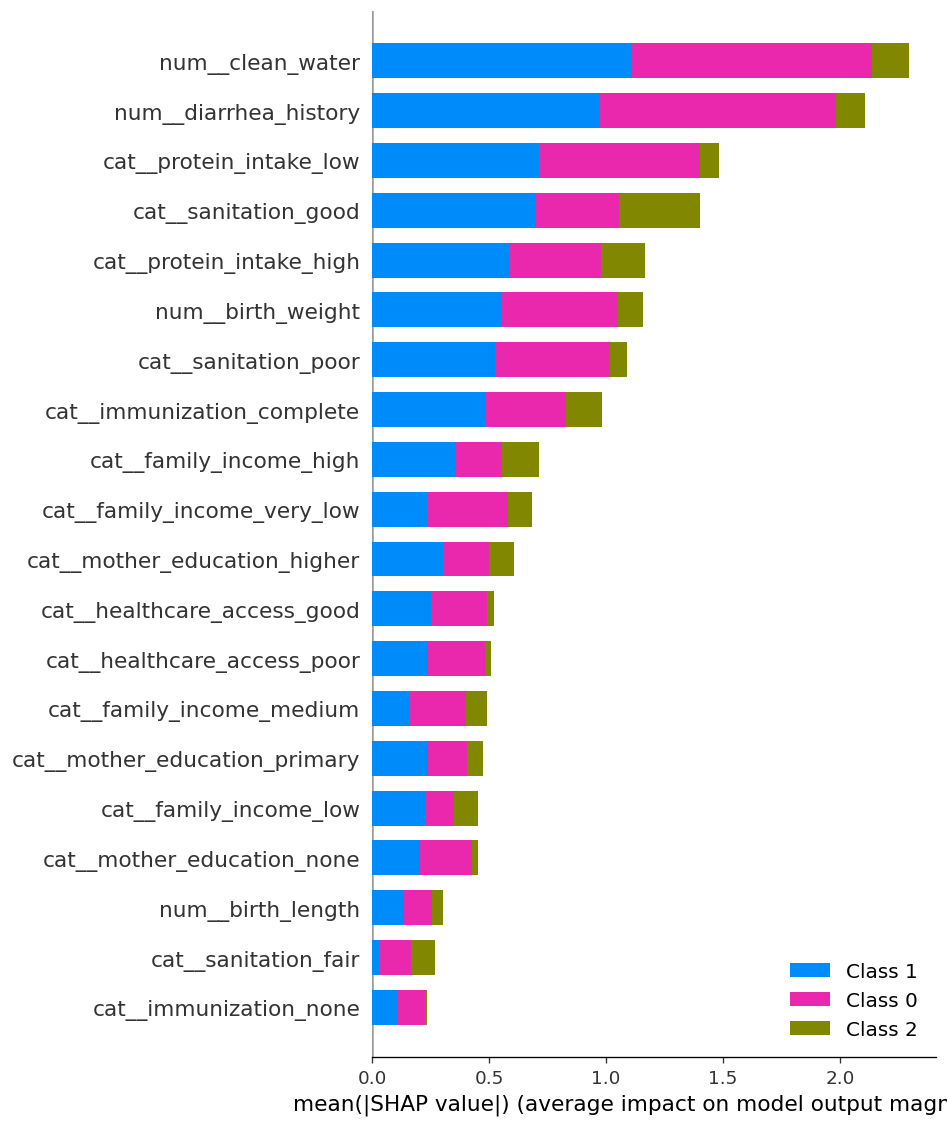

In [32]:
# Generate SHAP Summary Plot

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.tight_layout()

In [33]:
# Save Summary Plot

plt.savefig(
    SUMMARY_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Summary plot saved to:\n{SUMMARY_PLOT_PATH}")

<Figure size 1200x720 with 0 Axes>

Summary plot saved to:
/kaggle/working/model/explainability/shap_summary.png


In [34]:
# Summary Plot Information

print("=" * 60)
print("SHAP Summary Plot")
print("=" * 60)

print(f"Samples  : {len(X_shap)}")
print(f"Features : {X_shap.shape[1]}")

print()

print("Plot saved successfully.")

print("=" * 60)

SHAP Summary Plot
Samples  : 300
Features : 42

Plot saved successfully.


## Interpretation

The SHAP Summary Plot can be interpreted as follows:

- Features at the top have the greatest overall influence on model predictions.
- Positive SHAP values push predictions toward higher-risk classes.
- Negative SHAP values push predictions toward lower-risk classes.
- The horizontal spread indicates how strongly a feature affects different samples.
- Color represents the original feature value, allowing identification of whether high or low values increase prediction risk.

# 10. SHAP Bar Plot

The SHAP Bar Plot summarizes the global importance of each feature.

Unlike the Summary Plot, this visualization focuses only on the average magnitude of each feature's contribution without displaying the distribution across samples.

This plot is useful for:

- Reports
- Documentation
- Model comparison
- Executive summaries

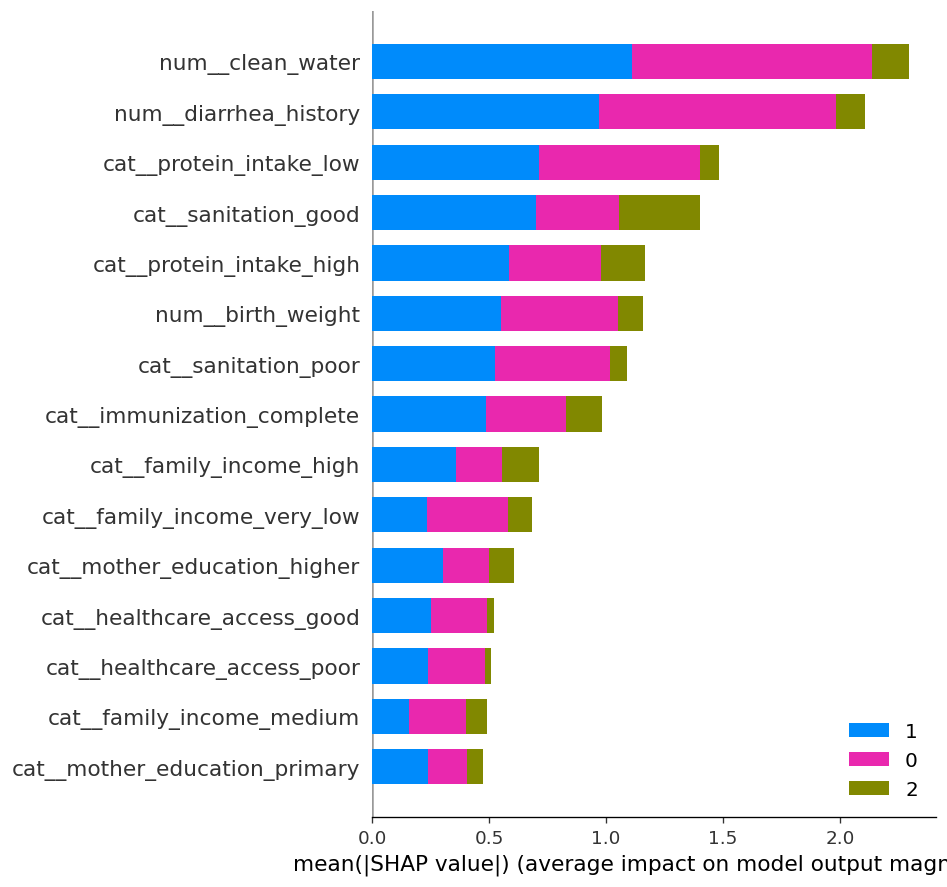

In [35]:
# Generate SHAP Bar Plot (Multiclass Compatible)
plt.figure(figsize=(10, 8))

num_classes = shap_values.values.shape[2]
shap_values_list = [shap_values.values[:, :, i] for i in range(num_classes)]

shap.summary_plot(
    shap_values_list, 
    X_shap, 
    plot_type="bar", 
    max_display=15, 
    show=False,
    class_names=final_model.classes_  # Menambahkan legenda nama kelas asli
)

plt.tight_layout()

In [36]:
# Save SHAP Bar Plot

plt.savefig(
    BAR_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Bar plot saved to:\n{BAR_PLOT_PATH}")

<Figure size 1200x720 with 0 Axes>

Bar plot saved to:
/kaggle/working/model/explainability/shap_bar.png


In [37]:
# Top Global Features

TOP_N = 10

display(global_importance.head(TOP_N))

,feature,mean_abs_shap
0,num__clean_water,0.765337
1,num__diarrhea_history,0.702203
2,cat__protein_intake_low,0.494898
3,cat__sanitation_good,0.467907
4,cat__protein_intake_high,0.389165
5,num__birth_weight,0.385411
6,cat__sanitation_poor,0.363370
7,cat__immunization_complete,0.327436
8,cat__family_income_high,0.237961
9,cat__family_income_very_low,0.228163


## Interpretation

The SHAP Bar Plot ranks features according to their average absolute SHAP values.

Key observations:

- Features at the top contribute the most to model predictions.
- Larger bars indicate greater overall influence.
- The plot does not indicate whether a feature increases or decreases prediction risk.
- For directional effects, refer to the SHAP Summary Plot or Waterfall Plot.

# 11. Local Explanation

Global explanations describe how the model behaves on average.

This section focuses on explaining a single prediction made by the model.

The selected sample will be reused throughout the remaining local explainability visualizations, including:

- Waterfall Plot
- Decision Plot
- Force Plot

Using the same sample ensures consistency across all local explanations.

In [38]:
# Select Sample for Local Explanation

SAMPLE_INDEX = 0

sample_features = X_shap.iloc[[SAMPLE_INDEX]]

sample_explanation = shap_values[SAMPLE_INDEX]

print(f"Selected sample index : {SAMPLE_INDEX}")

Selected sample index : 0


In [39]:
# Model Prediction

sample_raw = X_test.loc[[sample_features.index[0]]]
predicted_label_encoded = best_pipeline.predict(sample_raw)[0]
predicted_label = label_encoder.inverse_transform(
    [predicted_label_encoded]
)[0]
predicted_probability = best_pipeline.predict_proba(sample_raw)[0]
predicted_class_index = np.argmax(predicted_probability)
predicted_confidence = predicted_probability[predicted_class_index]

In [40]:
# True Label

true_label = y_test.loc[sample_features.index[0]]

print(f"True Label      : {true_label}")
print(f"Predicted Label : {predicted_label}")
print(f"Confidence      : {predicted_confidence:.2%}")

True Label      : Medium
Predicted Label : Medium
Confidence      : 98.95%


In [41]:
# Prediction Probability

probability_table = pd.DataFrame({
    "Class": label_encoder.classes_,
    "Probability": predicted_probability
})

probability_table["Probability"] = (
    probability_table["Probability"] * 100
).round(2)

display(probability_table)

,Class,Probability
0,High,0.12
1,Low,0.92
2,Medium,98.95


In [42]:
# Selected Sample Features
display(sample_raw.T.rename(columns={sample_raw.index[0]: "Value"}))

,Value
age_month,3
birth_weight,3.5
birth_length,51.8
mother_age,31.0
mother_working,1
father_working,1.0
clean_water,1
electricity,1
exclusive_breastfeeding,1.0
diarrhea_history,1


In [43]:
# Local Explanation Summary

print("=" * 60)
print("Local Explanation Summary")
print("=" * 60)

print(f"Sample Index      : {sample_raw.index[0]}")
print(f"True Label        : {true_label}")
print(f"Predicted Label   : {predicted_label}")
print(f"Confidence        : {predicted_confidence:.2%}")

print("=" * 60)

Local Explanation Summary
Sample Index      : 1116
True Label        : Medium
Predicted Label   : Medium
Confidence        : 98.95%


# 12. SHAP Waterfall Plot

The SHAP Waterfall Plot explains how individual feature contributions combine to produce a single prediction.

Starting from the model's baseline prediction, each feature pushes the prediction either higher or lower until the final output is reached.

This visualization provides a detailed explanation for one selected sample.

In [44]:
# Inspect SHAP Explanation

print(type(sample_explanation))
print(sample_explanation.values.shape)

<class 'shap._explanation.Explanation'>
(42, 3)


In [45]:
# Select Explanation for Predicted Class

if sample_explanation.values.ndim == 1:

    waterfall_explanation = sample_explanation

else:

    waterfall_explanation = shap.Explanation(
        values=sample_explanation.values[:, predicted_class_index],
        base_values=sample_explanation.base_values[predicted_class_index],
        data=sample_explanation.data,
        feature_names=sample_explanation.feature_names,
    )

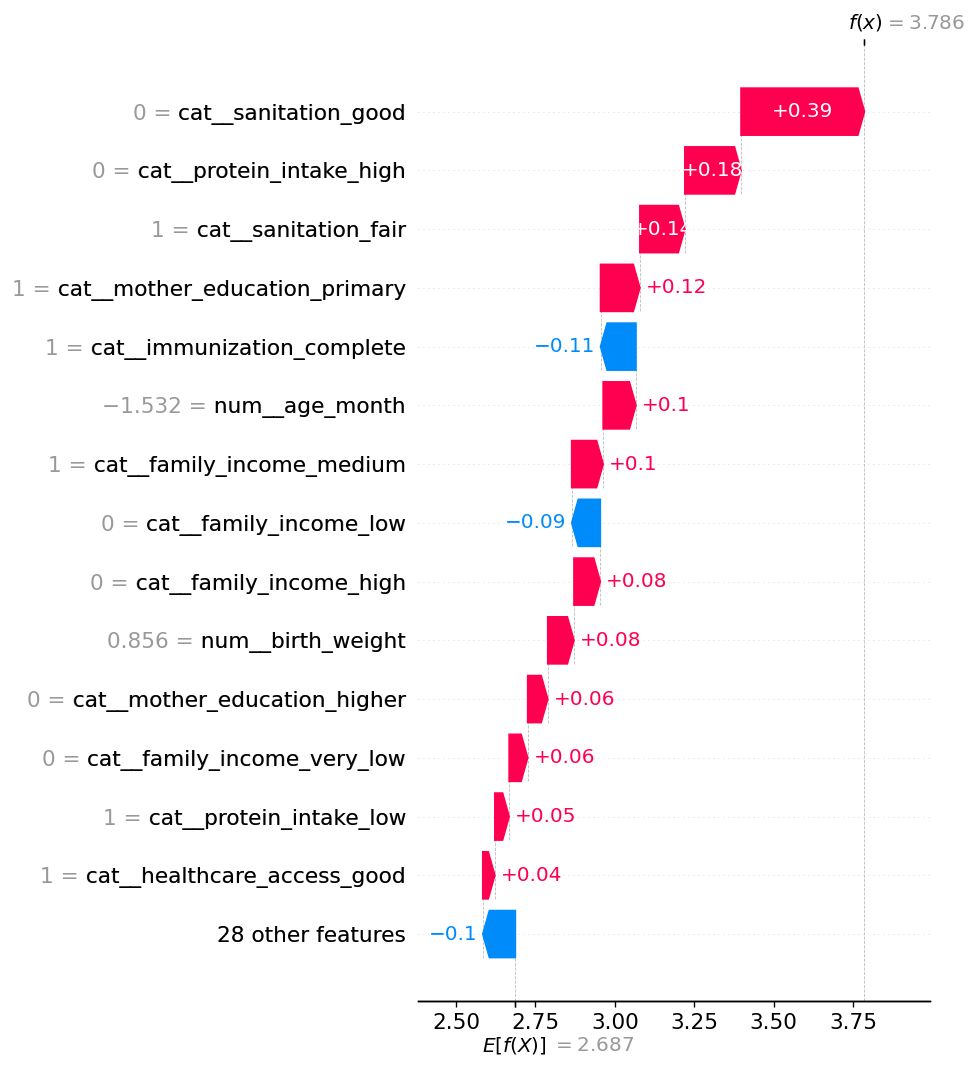

In [46]:
# Generate Waterfall Plot

plt.figure(figsize=(12, 8))

shap.plots.waterfall(
    waterfall_explanation,
    max_display=15,
    show=False
)

plt.tight_layout()

In [47]:
# Save Waterfall Plot

plt.savefig(
    WATERFALL_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Waterfall plot saved to:\n{WATERFALL_PLOT_PATH}")

<Figure size 1200x720 with 0 Axes>

Waterfall plot saved to:
/kaggle/working/model/explainability/waterfall.png


In [48]:
# Top Local Feature Contributions

local_importance = pd.DataFrame({
    "feature": waterfall_explanation.feature_names,
    "shap_value": waterfall_explanation.values,
    "abs_shap": np.abs(waterfall_explanation.values)
})

local_importance = (
    local_importance
    .sort_values("abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(local_importance.head(10))

,feature,shap_value,abs_shap
0,cat__sanitation_good,0.388695,0.388695
1,cat__protein_intake_high,0.176826,0.176826
2,cat__sanitation_fair,0.141634,0.141634
3,cat__mother_education_primary,0.123842,0.123842
4,cat__immunization_complete,-0.111460,0.111460
5,num__age_month,0.103211,0.103211
6,cat__family_income_medium,0.099023,0.099023
7,cat__family_income_low,-0.090009,0.090009
8,cat__family_income_high,0.082940,0.082940
9,num__birth_weight,0.082511,0.082511


## Interpretation

The Waterfall Plot explains one prediction step by step.

- Features with positive SHAP values increase the likelihood of the predicted class.
- Features with negative SHAP values decrease the likelihood of the predicted class.
- Larger absolute SHAP values indicate stronger influence.
- The sum of all SHAP contributions plus the base value equals the model output for the selected prediction.

# 13. SHAP Decision Plot

The SHAP Decision Plot visualizes how feature contributions accumulate from the model's expected value to the final prediction.

Unlike the Waterfall Plot, which emphasizes individual feature effects, the Decision Plot illustrates the sequential decision-making process of the model.

This visualization is particularly useful for understanding how multiple features jointly influence a prediction.

In [49]:
# Prepare Decision Plot Inputs

decision_values = waterfall_explanation.values
decision_base_value = waterfall_explanation.base_values

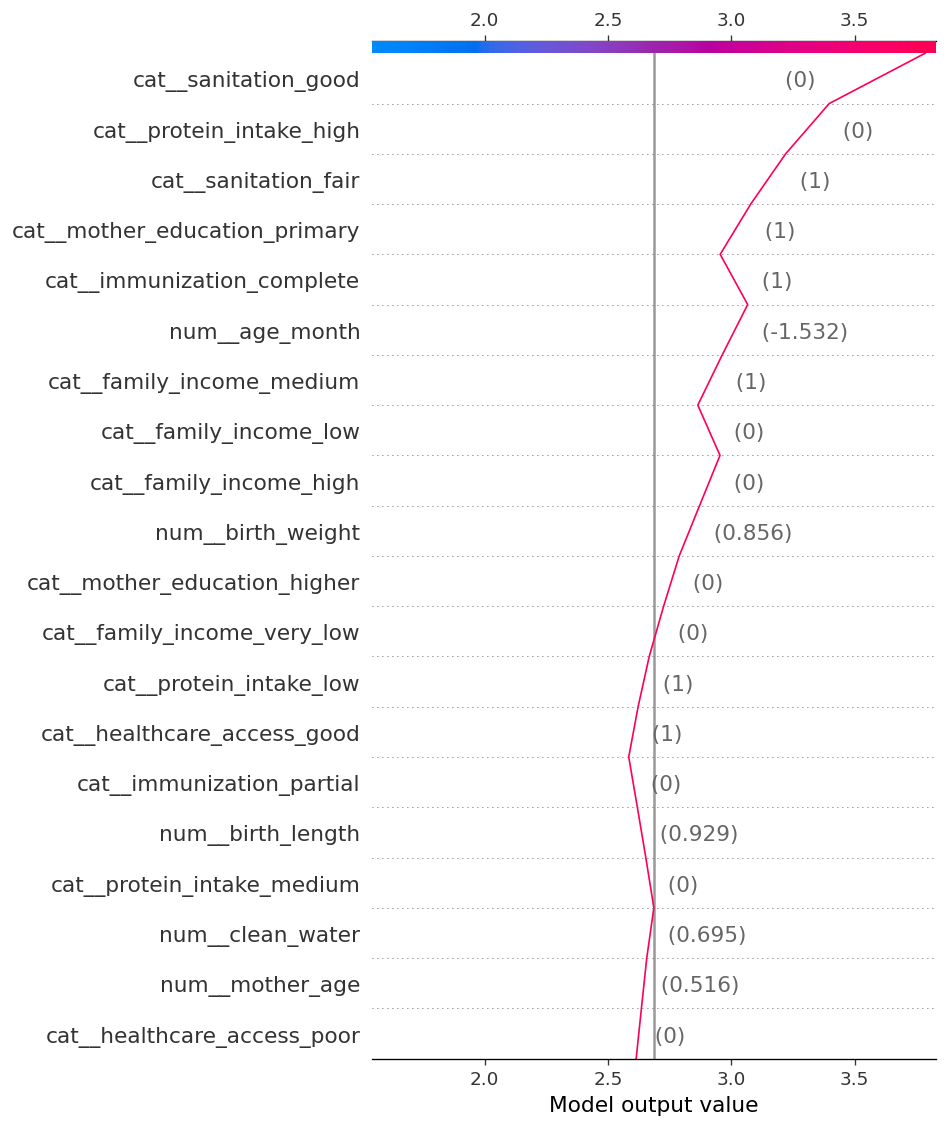

In [50]:
# Generate SHAP Decision Plot

plt.figure(figsize=(12, 8))

shap.decision_plot(
    base_value=decision_base_value,
    shap_values=decision_values,
    features=sample_features.iloc[0],
    feature_names=sample_features.columns.tolist(),
    show=False,
)

plt.tight_layout()
plt.show()

In [51]:
# Save Decision Plot

plt.savefig(
    DECISION_PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Decision plot saved to:\n{DECISION_PLOT_PATH}")

<Figure size 1200x720 with 0 Axes>

Decision plot saved to:
/kaggle/working/model/explainability/decision_plot.png


## Interpretation

The Decision Plot illustrates how the prediction evolves as each feature contributes to the final output.

Key observations:

- The plot starts from the model's expected prediction (base value).
- Each feature shifts the prediction higher or lower.
- The cumulative effect of all features results in the final prediction.
- Features with larger movements have greater influence on the model's decision.

# 14. SHAP Force Plot

The SHAP Force Plot provides an interactive visualization explaining a single prediction.

It illustrates how each feature pushes the prediction away from the model's expected value toward the final prediction.

Unlike static plots, the Force Plot is interactive and can be embedded into web applications, making it especially useful for future FastAPI integration.

In [52]:
# Generate SHAP Force Plot

force_plot = shap.plots.force(
    waterfall_explanation.base_values,
    waterfall_explanation.values,
    waterfall_explanation.data,
    feature_names=waterfall_explanation.feature_names,
    matplotlib=False,
)

In [53]:
# Save Force Plot

shap.save_html(
    str(FORCE_PLOT_PATH),
    force_plot,
)

print(f"Force plot saved to:\n{FORCE_PLOT_PATH}")

Force plot saved to:
/kaggle/working/model/explainability/force_plot.html


In [54]:
force_plot

## Interpretation

The Force Plot explains a single prediction by visualizing how individual feature contributions move the prediction away from the expected value.

Interpretation guidelines:

- Red features increase the prediction toward the predicted class.
- Blue features decrease the prediction.
- The final prediction is obtained by combining all feature contributions with the model's expected value.

This interactive visualization is especially useful for demonstrating prediction transparency in web applications.

# 15. SHAP Dependence Plot

The SHAP Dependence Plot visualizes how the value of a feature influences its SHAP value across multiple samples.

Unlike global importance plots, the dependence plot reveals:

- nonlinear relationships
- threshold effects
- feature interactions

The most important feature is automatically selected based on global SHAP importance.

In [55]:
# Select Most Important Feature

DEPENDENCE_FEATURE = global_importance.iloc[0]["feature"]

print("Selected feature:")
print(DEPENDENCE_FEATURE)

Selected feature:
num__clean_water


<Figure size 1200x720 with 0 Axes>

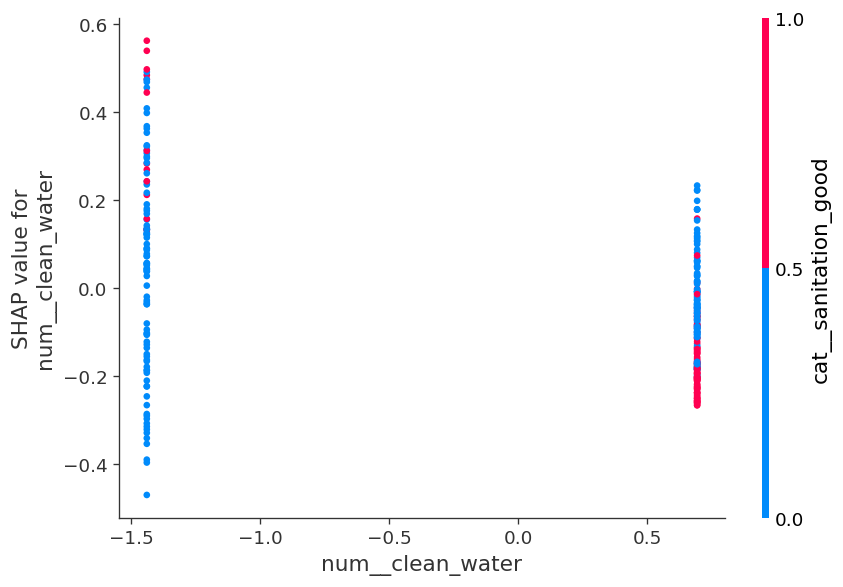

In [56]:
# Generate Dependence Plot

target_class_index = 2

plt.figure(figsize=(10, 6))

shap.dependence_plot(
    DEPENDENCE_FEATURE,
    shap_values.values[:, :, target_class_index],
    X_shap,
    interaction_index="auto",
    show=False,
)

plt.tight_layout()
plt.show()

In [57]:
# Save Dependence Plot

plt.savefig(
    DEPENDENCE_PLOT_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Dependence plot saved to:\n{DEPENDENCE_PLOT_PATH}")

<Figure size 1200x720 with 0 Axes>

Dependence plot saved to:
/kaggle/working/model/explainability/dependence.png


## Interpretation

The Dependence Plot illustrates how changes in a feature's value affect its contribution to the model prediction.

Key observations:

- Each point represents one sample.
- The x-axis shows the original feature value.
- The y-axis shows the SHAP value.
- Color indicates interaction with another feature (selected automatically).

Patterns to look for include:

- monotonic relationships
- nonlinear effects
- interaction between variables
- potential thresholds

# 16. SHAP Interaction Analysis (Optional)

Some tree-based models support SHAP interaction values, allowing analysis of how pairs of features jointly influence model predictions.

Because interaction values are not available for every estimator, this section performs the analysis only when supported.

If interaction values are unavailable, the notebook will skip this step gracefully.

In [58]:
# Check Interaction Support

interaction_supported = (
    shap_strategy == "TreeExplainer"
    and hasattr(explainer, "shap_interaction_values")
)

print("Interaction Analysis")

print(f"Supported : {interaction_supported}")

Interaction Analysis
Supported : True


In [59]:
# Compute Interaction Values

interaction_values = None

if interaction_supported:

    try:

        interaction_values = explainer.shap_interaction_values(X_shap)

        print("Interaction values computed successfully.")

    except Exception as e:

        print("Interaction values are not available.")
        print(e)

else:

    print("Current model does not support SHAP interaction values.")

Interaction values computed successfully.


In [60]:
# Interaction Summary

if interaction_values is not None:

    print(type(interaction_values))

    if isinstance(interaction_values, list):

        print("Multiclass interaction values detected.")

    else:

        print("Interaction matrix shape:")

        print(interaction_values.shape)

<class 'list'>
Multiclass interaction values detected.


<Figure size 1440x960 with 0 Axes>

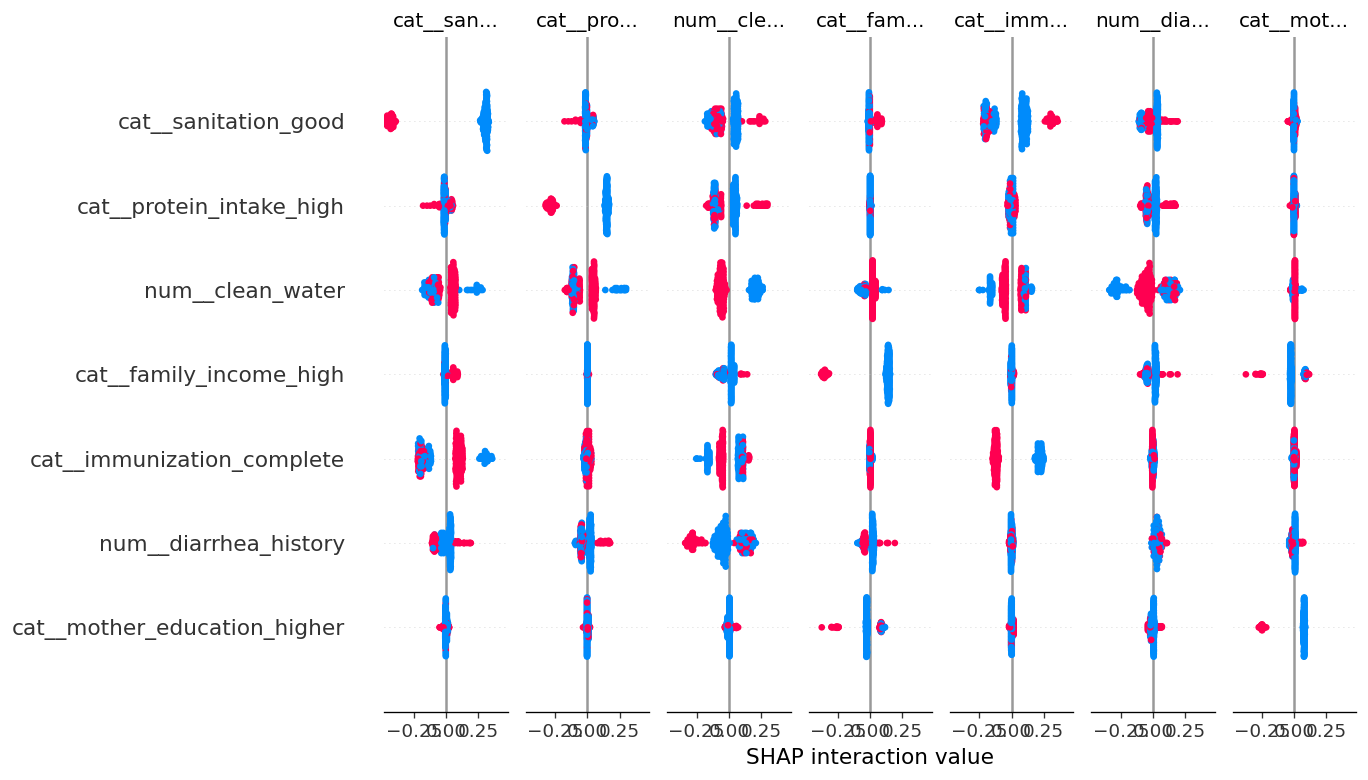

In [61]:
target_class_index = 2 

# Interaction Summary Plot
if interaction_values is not None:
    plt.figure(figsize=(12, 8))
    
    class_interaction_values = interaction_values[target_class_index]
    
    shap.summary_plot(
        class_interaction_values,
        X_shap,
        show=False,
    )
    
    plt.tight_layout()
    plt.show()
else:
    print("Interaction summary plot skipped.")

## Interpretation

Interaction values quantify how two features jointly influence the model prediction.

Interpretation guidelines:

- Strong interaction values indicate that two features work together to affect the prediction.
- Weak interaction values suggest that features contribute mostly independently.
- This analysis is only available for supported tree-based models.

# 17. Save Explainability Results

This section exports explainability artifacts generated throughout the notebook.

The exported files include:

- Feature importance ranking
- Explainability metadata
- Summary statistics

These artifacts are intended for documentation, reporting, and future FastAPI integration.

In [62]:
# Save Feature Importance

global_importance.to_csv(
    FEATURE_IMPORTANCE_CSV,
    index=False
)

print(f"Feature importance saved to:\n{FEATURE_IMPORTANCE_CSV}")

Feature importance saved to:
/kaggle/working/model/explainability/feature_importance.csv


In [63]:
# Build Explainability Summary

top_features = (
    global_importance
    .head(10)
    .to_dict(orient="records")
)

explanation_summary = {
    "project": "early-stunting-risk-ai",
    "explainability_method": "SHAP",
    "model": type(final_model).__name__,
    "explainer": type(explainer).__name__,
    "random_seed": RANDOM_SEED,
    "samples_analyzed": int(len(X_shap)),
    "features_analyzed": int(X_shap.shape[1]),
    "selected_sample_index": int(sample_raw.index[0]),
    "predicted_label": str(predicted_label),
    "true_label": str(true_label),
    "prediction_confidence": float(predicted_confidence),
    "top_features": top_features,
}

In [64]:
# Save Explanation Summary

with open(
    EXPLANATION_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        explanation_summary,
        f,
        indent=4,
        ensure_ascii=False,
    )

print(f"Explanation summary saved to:\n{EXPLANATION_SUMMARY_PATH}")

Explanation summary saved to:
/kaggle/working/model/explainability/explanation_summary.json


In [65]:
# Export Summary

exported_files = [
    SUMMARY_PLOT_PATH,
    BAR_PLOT_PATH,
    WATERFALL_PLOT_PATH,
    DEPENDENCE_PLOT_PATH,
    DECISION_PLOT_PATH,
    FORCE_PLOT_PATH,
    FEATURE_IMPORTANCE_CSV,
    EXPLANATION_SUMMARY_PATH,
]

print("=" * 60)
print("Explainability Artifacts")
print("=" * 60)

for path in exported_files:

    status = "OK" if path.exists() else "MISSING"

    print(f"{status:<8} {path.name}")

print("=" * 60)

Explainability Artifacts
OK       shap_summary.png
OK       shap_bar.png
OK       waterfall.png
OK       dependence.png
OK       decision_plot.png
OK       force_plot.html
OK       feature_importance.csv
OK       explanation_summary.json


# 18. Summary

This notebook successfully generated Explainable AI artifacts using the trained machine learning pipeline.

The workflow included:

1. Loading trained model artifacts.
2. Loading the test dataset.
3. Initializing the appropriate SHAP explainer.
4. Computing SHAP values.
5. Producing both global and local explanations.
6. Exporting explainability artifacts.

No model retraining was performed.

The generated outputs are ready for:

- Project documentation
- Model evaluation
- FastAPI backend integration
- Future dashboard visualization

In [66]:
# Explainable AI Summary

summary_table = pd.DataFrame({
    "Component": [
        "Pipeline Loaded",
        "Test Dataset Loaded",
        "SHAP Explainer",
        "SHAP Values Computed",
        "Global Explanation",
        "Local Explanation",
        "Summary Plot",
        "Bar Plot",
        "Waterfall Plot",
        "Decision Plot",
        "Force Plot",
        "Dependence Plot",
        "Feature Importance CSV",
        "Explanation Summary JSON"
    ],
    "Status": [
        "SUCCESS",
        "SUCCESS",
        "SUCCESS",
        "SUCCESS",
        "SUCCESS",
        "SUCCESS",
        "SUCCESS",
        "SUCCESS",
        "SUCCESS",
        "SUCCESS",
        "SUCCESS",
        "SUCCESS",
        "SUCCESS",
        "SUCCESS"
    ]
})

display(summary_table)

,Component,Status
0,Pipeline Loaded,SUCCESS
1,Test Dataset Loaded,SUCCESS
2,SHAP Explainer,SUCCESS
3,SHAP Values Computed,SUCCESS
4,Global Explanation,SUCCESS
5,Local Explanation,SUCCESS
6,Summary Plot,SUCCESS
7,Bar Plot,SUCCESS
8,Waterfall Plot,SUCCESS
9,Decision Plot,SUCCESS


In [67]:
# Generated Files

generated_files = [
    SUMMARY_PLOT_PATH,
    BAR_PLOT_PATH,
    WATERFALL_PLOT_PATH,
    DECISION_PLOT_PATH,
    DEPENDENCE_PLOT_PATH,
    FORCE_PLOT_PATH,
    FEATURE_IMPORTANCE_CSV,
    EXPLANATION_SUMMARY_PATH,
]

generated_df = pd.DataFrame({
    "Filename": [path.name for path in generated_files],
    "Exists": [path.exists() for path in generated_files],
    "Location": [str(path) for path in generated_files],
})

display(generated_df)

,Filename,Exists,Location
0,shap_summary.png,True,/kaggle/working/model/explainability/shap_summ...
1,shap_bar.png,True,/kaggle/working/model/explainability/shap_bar.png
2,waterfall.png,True,/kaggle/working/model/explainability/waterfall...
3,decision_plot.png,True,/kaggle/working/model/explainability/decision_...
4,dependence.png,True,/kaggle/working/model/explainability/dependenc...
5,force_plot.html,True,/kaggle/working/model/explainability/force_plo...
6,feature_importance.csv,True,/kaggle/working/model/explainability/feature_i...
7,explanation_summary.json,True,/kaggle/working/model/explainability/explanati...


In [68]:
# Project Statistics

project_stats = {
    "Model": type(final_model).__name__,
    "Explainer": type(explainer).__name__,
    "Random Seed": RANDOM_SEED,
    "Samples Explained": len(X_shap),
    "Features": X_shap.shape[1],
    "Top Feature": global_importance.iloc[0]["feature"],
    "Prediction Example": predicted_label,
    "Prediction Confidence": f"{predicted_confidence:.2%}",
}

stats_df = pd.DataFrame(
    project_stats.items(),
    columns=["Metric", "Value"]
)

display(stats_df)

,Metric,Value
0,Model,CatBoostClassifier
1,Explainer,TreeExplainer
2,Random Seed,42
3,Samples Explained,300
4,Features,42
5,Top Feature,num__clean_water
6,Prediction Example,Medium
7,Prediction Confidence,98.95%


In [69]:
# Completion Message

print("=" * 70)
print("Explainable AI Pipeline Completed Successfully")
print("=" * 70)

print()
print("Generated artifacts:")
print(f"• {SUMMARY_PLOT_PATH.name}")
print(f"• {BAR_PLOT_PATH.name}")
print(f"• {WATERFALL_PLOT_PATH.name}")
print(f"• {DECISION_PLOT_PATH.name}")
print(f"• {DEPENDENCE_PLOT_PATH.name}")
print(f"• {FORCE_PLOT_PATH.name}")
print(f"• {FEATURE_IMPORTANCE_CSV.name}")
print(f"• {EXPLANATION_SUMMARY_PATH.name}")

print()
print("Output directory:")
print(EXPLAINABILITY_DIR)

print()
print("Notebook execution completed successfully.")
print("=" * 70)

Explainable AI Pipeline Completed Successfully

Generated artifacts:
• shap_summary.png
• shap_bar.png
• waterfall.png
• decision_plot.png
• dependence.png
• force_plot.html
• feature_importance.csv
• explanation_summary.json

Output directory:
/kaggle/working/model/explainability

Notebook execution completed successfully.


In [70]:
import shutil

folder_yang_di_zip = '/kaggle/working/model'
nama_file_output = '/kaggle/working/explainability_model'

shutil.make_archive(nama_file_output, 'zip', folder_yang_di_zip)
print("Folder 'model' berhasil dikompres menjadi file ZIP!")

Folder 'model' berhasil dikompres menjadi file ZIP!
